In [1]:
#import libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px
sns.set()

### importing and inspecting data

In [2]:
df=pd.read_csv('retail_sales_dataset.csv')
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [4]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [5]:
df['Gender'].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

### processinf Data


In [6]:
df.isna().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# Convert Date column type to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [10]:
df.columns=df.columns.str.lower().str.replace(' ','')
df.columns

Index(['transactionid', 'date', 'customerid', 'gender', 'age',
       'productcategory', 'quantity', 'priceperunit', 'totalamount'],
      dtype='object')

In [11]:
df.sample(10)

,transactionid,date,customerid,gender,age,productcategory,quantity,priceperunit,totalamount
355,356,2023-06-10,CUST356,Male,50,Electronics,3,500,1500
860,861,2023-02-17,CUST861,Female,41,Clothing,3,30,90
959,960,2023-08-08,CUST960,Male,59,Clothing,2,30,60
638,639,2023-05-13,CUST639,Female,62,Beauty,4,50,200
388,389,2023-12-01,CUST389,Male,21,Clothing,2,25,50
517,518,2023-05-11,CUST518,Female,40,Clothing,1,30,30
902,903,2023-04-27,CUST903,Female,51,Beauty,4,50,200
915,916,2023-12-24,CUST916,Female,32,Electronics,1,50,50
846,847,2023-04-08,CUST847,Female,18,Electronics,4,300,1200
561,562,2023-04-18,CUST562,Male,54,Electronics,2,25,50


In [13]:
df['month'] = df['date'].dt.month

In [14]:
df.sample(10)

,transactionid,date,customerid,gender,age,productcategory,quantity,priceperunit,totalamount,month
570,571,2023-12-12,CUST571,Female,41,Electronics,1,50,50,12
172,173,2023-11-08,CUST173,Male,64,Electronics,4,30,120,11
727,728,2023-07-14,CUST728,Male,51,Electronics,3,50,150,7
110,111,2023-04-19,CUST111,Female,34,Electronics,3,500,1500,4
291,292,2023-02-17,CUST292,Male,20,Beauty,4,300,1200,2
807,808,2023-04-01,CUST808,Male,33,Beauty,4,500,2000,4
648,649,2023-02-09,CUST649,Female,58,Clothing,2,300,600,2
234,235,2023-01-31,CUST235,Female,23,Electronics,2,500,1000,1
695,696,2023-09-06,CUST696,Female,50,Clothing,4,50,200,9
783,784,2023-11-04,CUST784,Female,34,Electronics,1,500,500,11


In [15]:
df.columns

Index(['transactionid', 'date', 'customerid', 'gender', 'age',
       'productcategory', 'quantity', 'priceperunit', 'totalamount', 'month'],
      dtype='object')

In [18]:
df=df[['transactionid','date','month', 'customerid', 'gender', 'age',
       'productcategory', 'quantity', 'priceperunit', 'totalamount']]
df

,transactionid,date,month,customerid,gender,age,productcategory,quantity,priceperunit,totalamount
0,1,2023-11-24,11,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,2,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,1,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,5,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,5,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,5,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,11,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,10,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,12,CUST999,Female,36,Electronics,3,50,150


### Exploring and Analysis data

Text(0, 0.5, 'TOtal Sales')

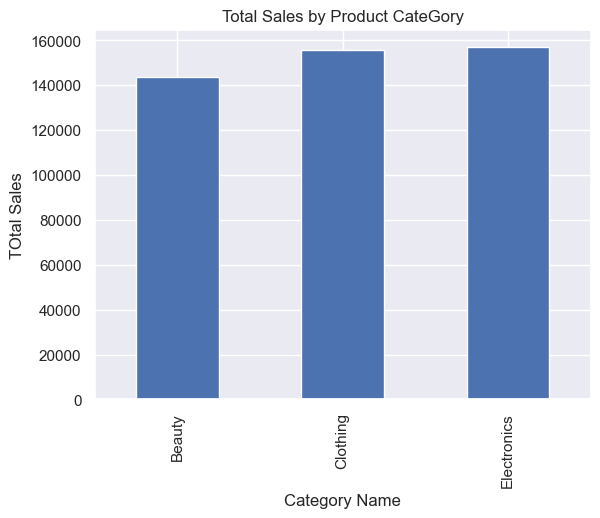

In [27]:
df.groupby('productcategory')['totalamount'].sum().plot(kind='bar',title='Total Sales by Product CateGory')
plt.xlabel('Category Name')
plt.ylabel("TOtal Sales")

In [47]:
numerical_cols = df.select_dtypes('number')
numerical_cols

,transactionid,month,age,quantity,priceperunit,totalamount
0,1,11,34,3,50,150
1,2,2,26,2,500,1000
2,3,1,50,1,30,30
3,4,5,37,1,500,500
4,5,5,30,2,50,100
...,...,...,...,...,...,...
995,996,5,62,1,50,50
996,997,11,52,3,30,90
997,998,10,23,4,25,100
998,999,12,36,3,50,150


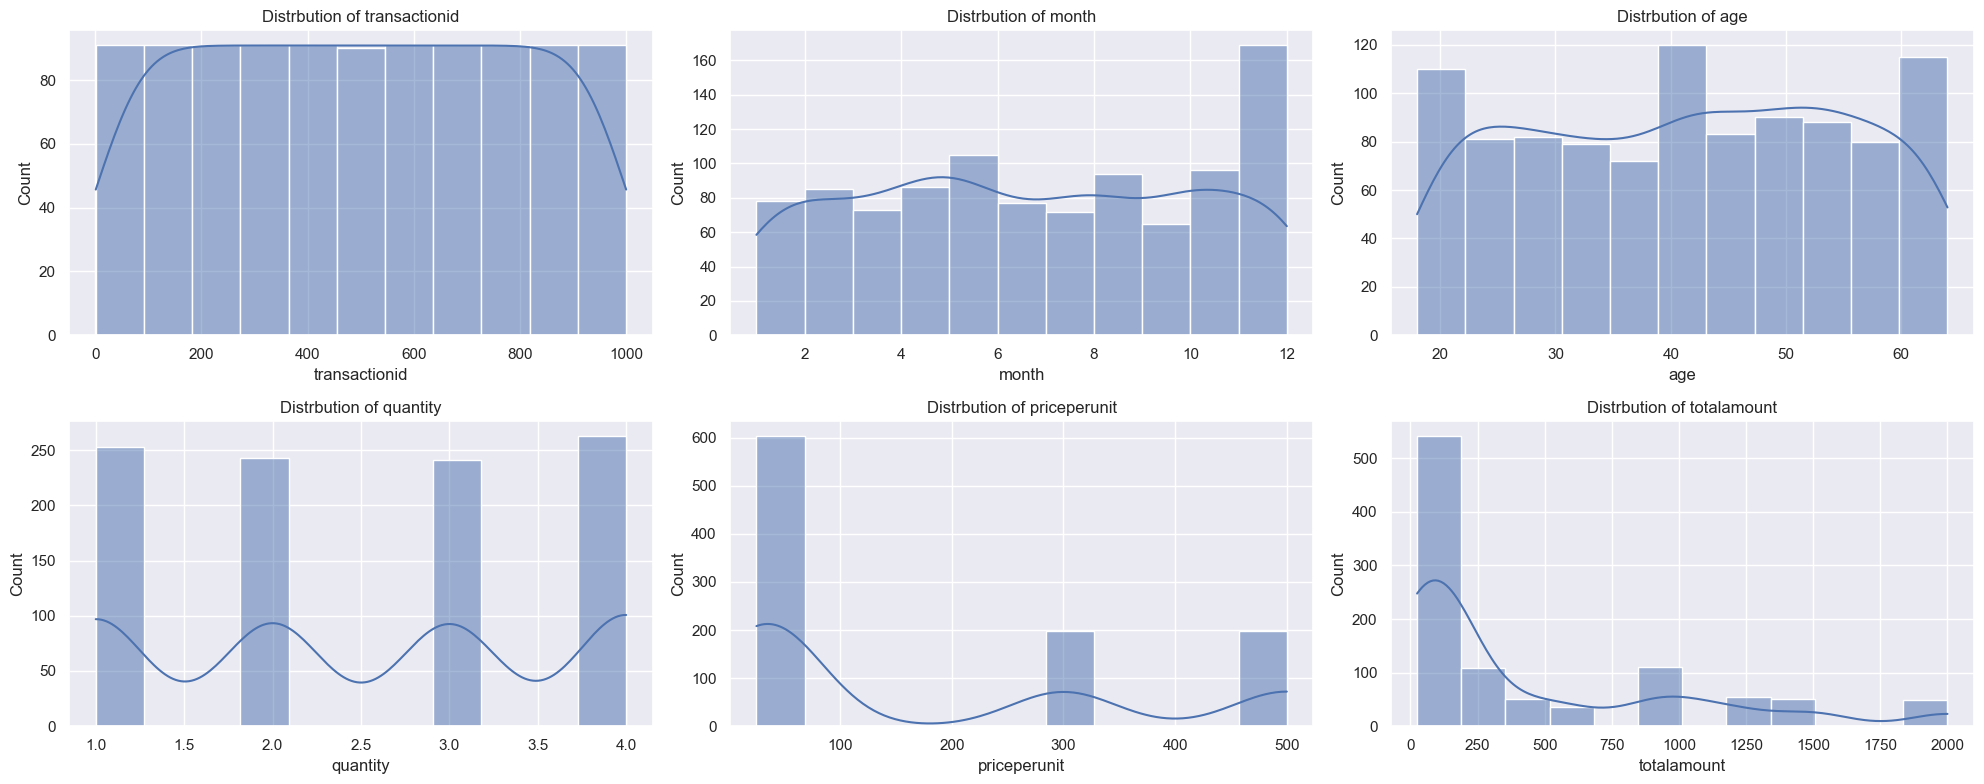

In [48]:
plt.figure(figsize=(20,8))
for e,i in enumerate(numerical_cols.columns):
    plt.subplot(2,3,e+1)
    sns.histplot(numerical_cols[i],kde=True)
    plt.title("Distrbution of " + i)
    plt.tight_layout()

In [53]:
objct_cols=df.select_dtypes('object')
objct_cols=objct_cols.iloc(:,1:)

SyntaxError: invalid syntax (86086072.py, line 2)

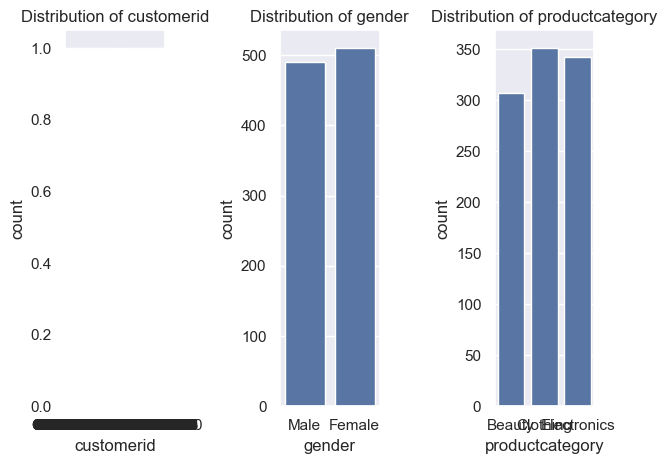

In [54]:
plt.Figure(figsize=(20,8))
for e,i in enumerate(objct_cols.columns):
    plt.subplot(1,3,e+1)
    sns.countplot(data=objct_cols,x=i)
    plt.title("Distribution of " + i)
    plt.tight_layout()

In [62]:
grouping=df.groupby(['gender','age'],as_index=False)['totalamount'].count()

In [63]:
grouping

,gender,age,totalamount
0,Female,18,13
1,Female,19,11
2,Female,20,12
3,Female,21,7
4,Female,22,14
...,...,...,...
89,Male,60,9
90,Male,61,12
91,Male,62,16
92,Male,63,11


In [64]:
fig = px.bar(data_frame=grouping , x= 'gender', y='age',color='totalamount',title="the age and gender of customer")

In [65]:
fig.show()

In [66]:
df.to_csv('retial.csv',index=False)

In [72]:
df['productcategory'].unique()

array(['Beauty', 'Clothing', 'Electronics'], dtype=object)

In [73]:
df['prodid']=df['productcategory']
df['prodid']=df['prodid'].replace(["Beauty","Clothing","Electronics"],[1,2,3])

C:\Users\mohammad\AppData\Local\Temp\ipykernel_1592\448422111.py:2: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [74]:
df['prodid']

0      1
1      2
2      3
3      2
4      1
      ..
995    2
996    1
997    1
998    3
999    3
Name: prodid, Length: 1000, dtype: int64

In [75]:
corr=df[['prodid','quantity']]

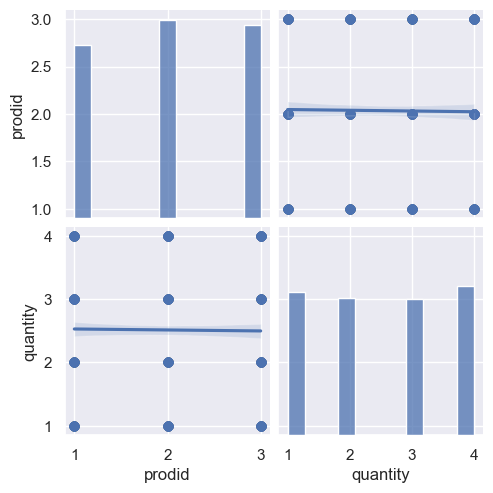

In [76]:
sns.pairplot(corr,kind='reg')

<Axes: >

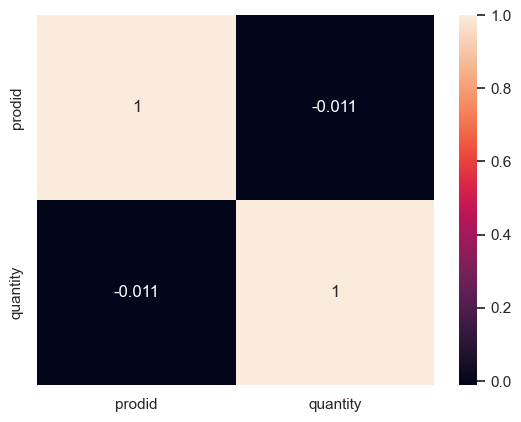

In [77]:
sns.heatmap(corr.corr(),annot=True)

* The type of product did not influence the quantity 

In [78]:
df['customerid'].nunique()

1000

In [80]:
df['age'].nunique()

47